In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
import sys
import os

REPO_PATH = "/content/drive/MyDrive/BraTS_Project/brats-brain-tumor"
SRC_PATH = os.path.join(REPO_PATH, "src")

if SRC_PATH not in sys.path:
    sys.path.append(SRC_PATH)

print(f"Added to path: {SRC_PATH}")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import numpy as np
import time
import nibabel as nib
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score

from dataset import BraTSDataGenerator
from preprocess import split_data
from model import hybrid_loss, dice_coefficient, build_model

Added to path: /content/drive/MyDrive/BraTS_Project/brats-brain-tumor/src


In [3]:
custom_objects = {
    'hybrid_loss': hybrid_loss,
    'dice_coefficient': dice_coefficient
}

models = {}
model_names = ["unet", "attention", "resunet"]

for name in model_names:
    model_path = os.path.join(REPO_PATH, f"models/best_{name}_model.keras")
    if os.path.exists(model_path):
        print(f"{name} is loading...")
        models[name] = tf.keras.models.load_model(model_path, custom_objects=custom_objects)
    else:
        print(f"Warning: {model_path} could not find!")



unet is loading...
attention is loading...
resunet is loading...


In [4]:
logs = {}
for name in model_names:
    log_path = os.path.join(REPO_PATH, f"models/{name}_training_log.csv")
    if os.path.exists(log_path):
        logs[name] = pd.read_csv(log_path)
    else:
        print(f"Warning: {log_path} could not find!")

# Example
if "attention" in logs:
    display(logs["attention"].head())

,epoch,accuracy,dice_coefficient,learning_rate,loss,val_accuracy,val_dice_coefficient,val_loss
0,0,0.369860,0.062162,0.0001,0.938621,0.028671,0.041022,0.961781
1,1,0.246043,0.087433,0.0001,0.913039,0.042193,0.048896,0.955730
2,2,0.187282,0.095510,0.0001,0.905063,0.027674,0.038197,0.966921
3,3,0.156277,0.107854,0.0001,0.893040,0.057813,0.048498,0.961395
4,4,0.148767,0.119865,0.0001,0.881135,0.085848,0.046555,0.964349


In [5]:
DATA_PATH = "/content/drive/MyDrive/BraTS_Project/data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

patient_ids = sorted([f for f in os.listdir(DATA_PATH) if f.startswith("BraTS20")])
_, _, test_ids = split_data(patient_ids)

test_gen = BraTSDataGenerator(test_ids, DATA_PATH, batch_size=1, shuffle=False)

print(f"Test data is ready: {len(test_ids)} Patient")

Test data is ready: 74 Patient


Comparative Analysis: Validation Dice Coefficient and Validation Loss

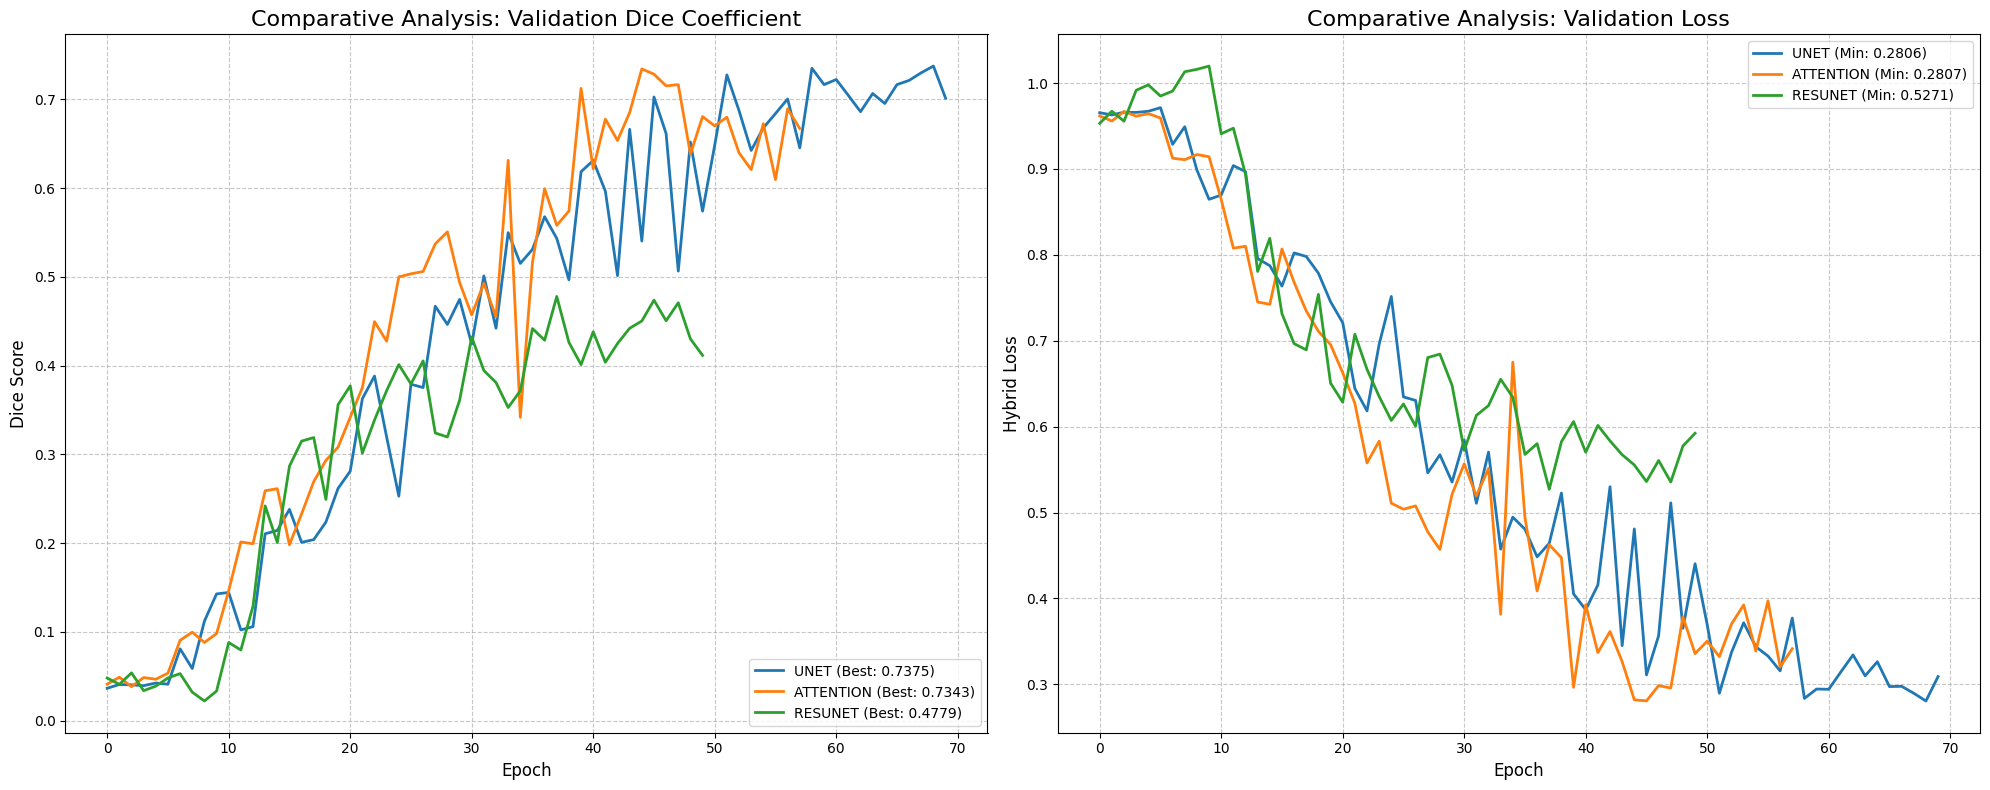

In [6]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

colors = {'unet': '#1f77b4', 'attention': '#ff7f0e', 'resunet': '#2ca02c'}

# Validation Dice Coefficient
for name, df in logs.items():
    ax1.plot(df['epoch'], df['val_dice_coefficient'],
             label=f'{name.upper()} (Best: {df["val_dice_coefficient"].max():.4f})',
             color=colors[name], linewidth=2)

ax1.set_title('Comparative Analysis: Validation Dice Coefficient', fontsize=16)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Dice Score', fontsize=12)
ax1.legend(loc='lower right')
ax1.grid(True, linestyle='--', alpha=0.7)

# Validation Loss
for name, df in logs.items():
    ax2.plot(df['epoch'], df['val_loss'],
             label=f'{name.upper()} (Min: {df["val_loss"].min():.4f})',
             color=colors[name], linewidth=2)

ax2.set_title('Comparative Analysis: Validation Loss', fontsize=16)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Hybrid Loss', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Summary Table

In [7]:
summary_data = []

for name, df in logs.items():
    best_dice = df['val_dice_coefficient'].max()
    min_loss = df['val_loss'].min()
    final_dice = df['val_dice_coefficient'].iloc[-1]

    summary_data.append({
        'Model Architecture': name.upper(),
        'Best Val Dice': f"{best_dice:.4f}",
        'Min Val Loss': f"{min_loss:.4f}",
        'Final Val Dice': f"{final_dice:.4f}"
    })

comparison_df = pd.DataFrame(summary_data)
print("--- Quantitative Performance Summary ---")
display(comparison_df)

--- Quantitative Performance Summary ---


,Model Architecture,Best Val Dice,Min Val Loss,Final Val Dice
0,UNET,0.7375,0.2806,0.7014
1,ATTENTION,0.7343,0.2807,0.6671
2,RESUNET,0.4779,0.5271,0.4115


Overfitting Analysis - Training vs Validation Loss

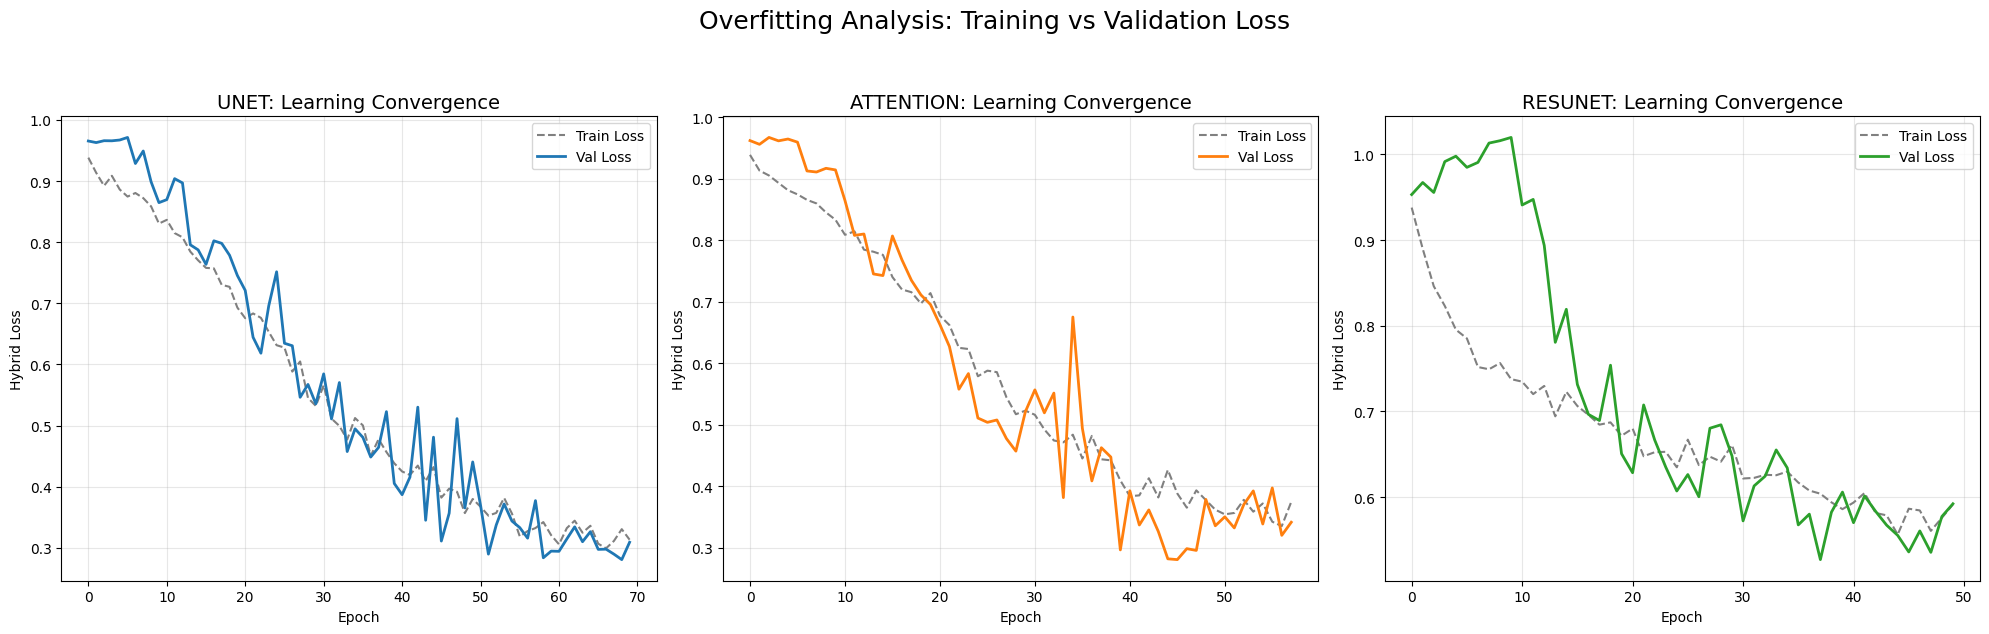

In [8]:
fig, axes = plt.subplots(1, len(logs), figsize=(20, 6))
if len(logs) == 1: axes = [axes]

for i, (name, df) in enumerate(logs.items()):
    axes[i].plot(df['epoch'], df['loss'], label='Train Loss', color='gray', linestyle='--')
    axes[i].plot(df['epoch'], df['val_loss'], label='Val Loss', color=colors[name], linewidth=2)
    axes[i].set_title(f'{name.upper()}: Learning Convergence', fontsize=14)
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Hybrid Loss')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Overfitting Analysis: Training vs Validation Loss', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

Accuracy Analysis

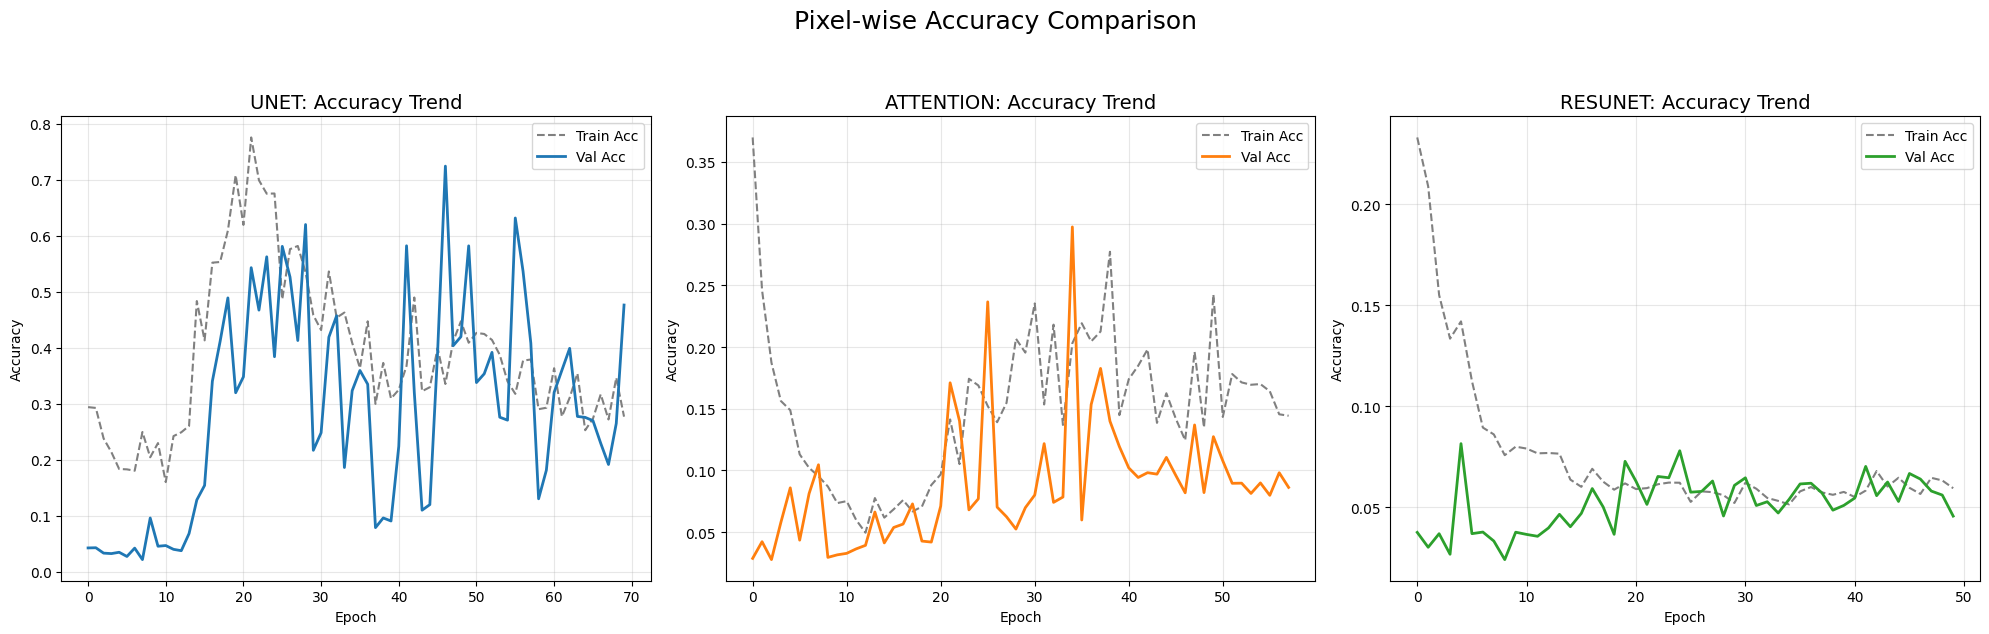

In [9]:
fig, axes = plt.subplots(1, len(logs), figsize=(20, 6))
if len(logs) == 1: axes = [axes]

for i, (name, df) in enumerate(logs.items()):
    axes[i].plot(df['epoch'], df['accuracy'], label='Train Acc', color='gray', linestyle='--')
    axes[i].plot(df['epoch'], df['val_accuracy'], label='Val Acc', color=colors[name], linewidth=2)
    axes[i].set_title(f'{name.upper()}: Accuracy Trend', fontsize=14)
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Accuracy')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Pixel-wise Accuracy Comparison', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

Learning Rate Schedule Analysis

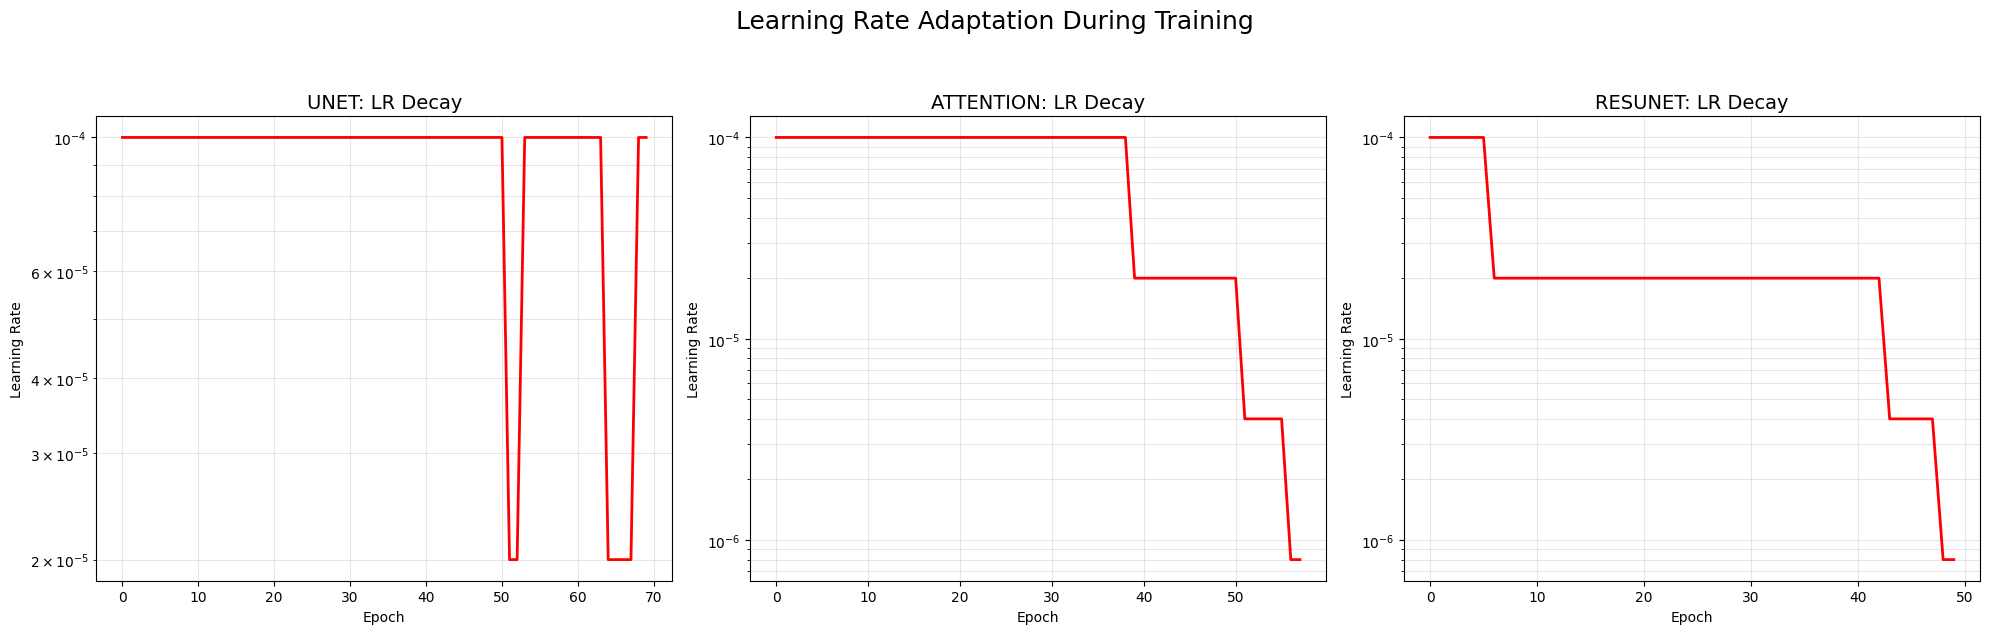

In [10]:
fig, axes = plt.subplots(1, len(logs), figsize=(20, 6))
if len(logs) == 1: axes = [axes]

for i, (name, df) in enumerate(logs.items()):
    axes[i].plot(df['epoch'], df['learning_rate'], color='red', linewidth=2)
    axes[i].set_title(f'{name.upper()}: LR Decay', fontsize=14)
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Learning Rate')
    axes[i].set_yscale('log')
    axes[i].grid(True, which="both", ls="-", alpha=0.3)

plt.suptitle('Learning Rate Adaptation During Training', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

Visual Inference - Positive Case

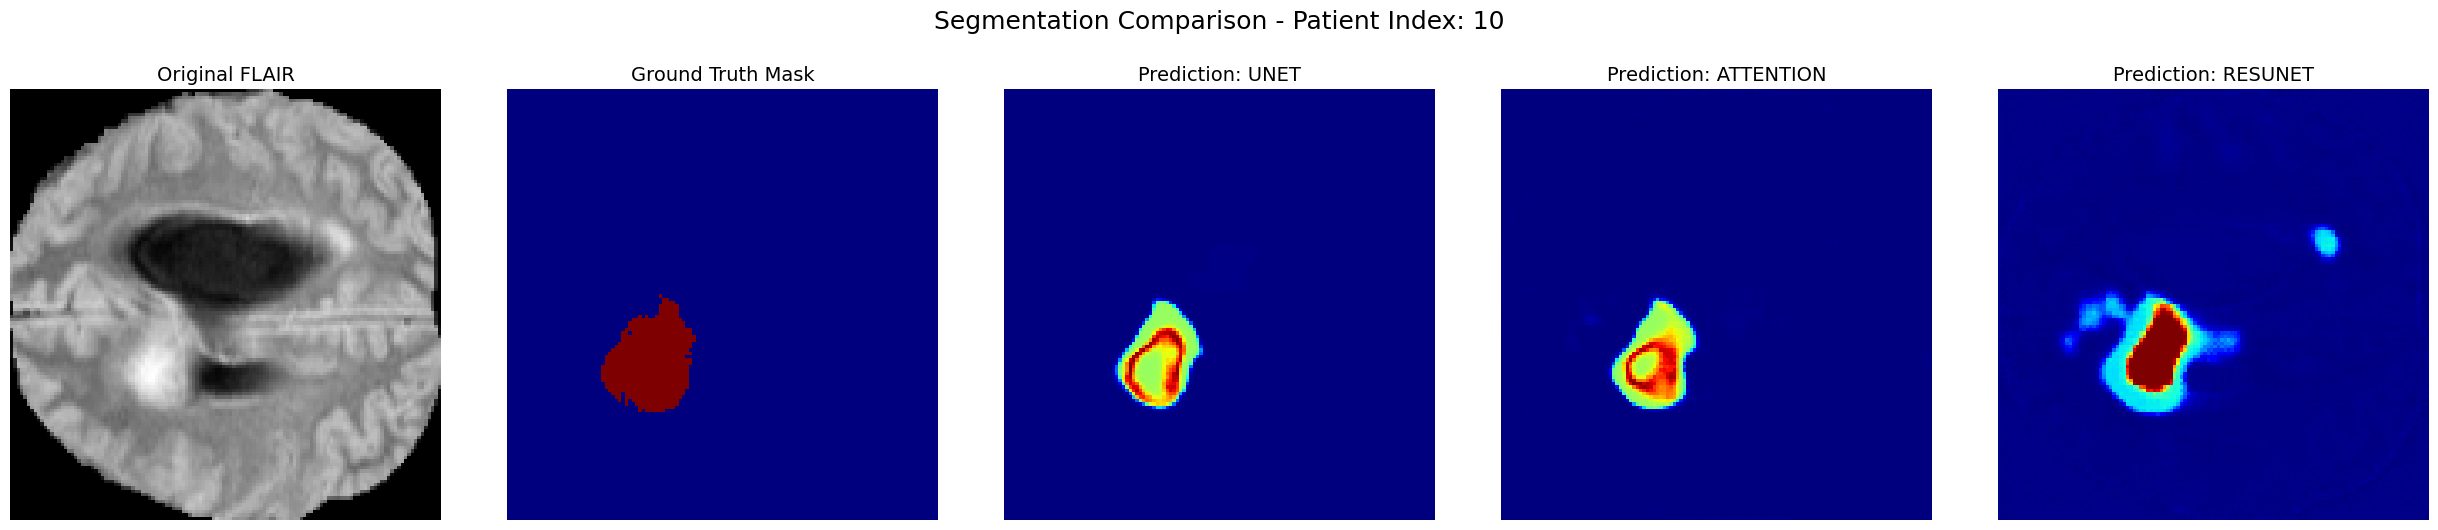

In [11]:
def visualize_predictions(model_dict, test_gen, slice_idx=None, patient_idx=0):
    X, y_true = test_gen[patient_idx]

    preds = {name: model.predict(X, verbose=0)[0] for name, model in model_dict.items()}

    fig, axes = plt.subplots(1, 5, figsize=(25, 5))

    axes[0].imshow(X[0, :, :, 0], cmap='gray')
    axes[0].set_title("Original FLAIR", fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(np.sum(y_true[0], axis=-1), cmap='jet')
    axes[1].set_title("Ground Truth Mask", fontsize=14)
    axes[1].axis('off')

    for i, (name, pred) in enumerate(preds.items()):
        axes[i+2].imshow(np.sum(pred, axis=-1), cmap='jet')
        axes[i+2].set_title(f"Prediction: {name.upper()}", fontsize=14)
        axes[i+2].axis('off')

    plt.suptitle(f"Segmentation Comparison - Patient Index: {patient_idx}", fontsize=18, y=1.05)
    plt.tight_layout()
    plt.show()

visualize_predictions(models, test_gen, patient_idx=10)

Visual Inference - Negative Case

Negative case found at Patient Index: 1


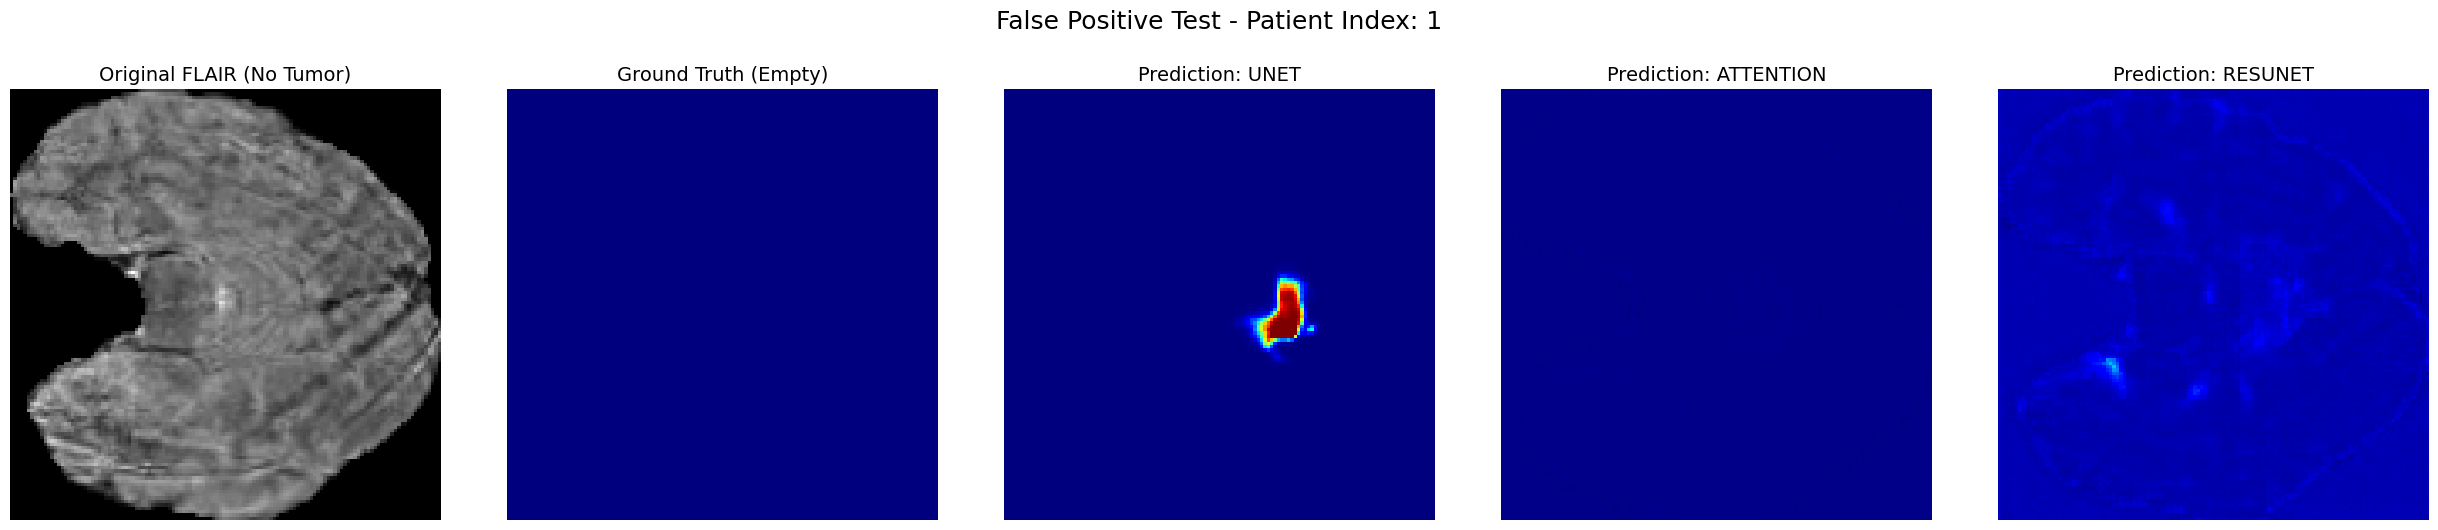

In [12]:
def find_and_visualize_negative_case(model_dict, test_gen):
    found = False
    for i in range(len(test_gen)):
        X, y_true = test_gen[i]

        if np.sum(y_true) == 0:
            print(f"Negative case found at Patient Index: {i}")

            preds = {name: model.predict(X, verbose=0)[0] for name, model in model_dict.items()}

            fig, axes = plt.subplots(1, 5, figsize=(25, 5))

            axes[0].imshow(X[0, :, :, 0], cmap='gray')
            axes[0].set_title("Original FLAIR (No Tumor)", fontsize=14)
            axes[0].axis('off')

            axes[1].imshow(np.sum(y_true[0], axis=-1), cmap='jet', vmin=0, vmax=1)
            axes[1].set_title("Ground Truth (Empty)", fontsize=14)
            axes[1].axis('off')

            for j, (name, pred) in enumerate(preds.items()):
                axes[j+2].imshow(np.sum(pred, axis=-1), cmap='jet', vmin=0, vmax=1)
                axes[j+2].set_title(f"Prediction: {name.upper()}", fontsize=14)
                axes[j+2].axis('off')

            plt.suptitle(f"False Positive Test - Patient Index: {i}", fontsize=18, y=1.05)
            plt.tight_layout()
            plt.show()

            found = True
            break

    if not found:
        print("No completely negative case found in the current test generator.")

find_and_visualize_negative_case(models, test_gen)

Per-Class Dice Analysis (NCR, ED, ET)

In [14]:
def calculate_per_class_dice(model_dict, test_gen):
    results = {name: {"NCR": [], "ED": [], "ET": []} for name in model_dict.keys()}

    print("Calculating per-class metrics on test set...")
    for i in tqdm(range(len(test_gen))):
        X, y_true = test_gen[i]
        y_true = y_true[0]

        for name, model in model_dict.items():
            y_pred = model.predict(X, verbose=0)[0]
            y_pred = (y_pred > 0.5).astype(np.float32)

            for ch_idx, label in enumerate(["NCR", "ED", "ET"]):
                intersection = np.sum(y_true[:, :, ch_idx] * y_pred[:, :, ch_idx])
                union = np.sum(y_true[:, :, ch_idx]) + np.sum(y_pred[:, :, ch_idx])

                if union == 0:
                    dice = 1.0
                else:
                    dice = (2. * intersection) / union
                results[name][label].append(dice)

    summary = []
    for name in model_dict.keys():
        summary.append({
            "Model": name.upper(),
            "NCR (Core)": f"{np.mean(results[name]['NCR']):.4f}",
            "ED (Edema)": f"{np.mean(results[name]['ED']):.4f}",
            "ET (Enhancing)": f"{np.mean(results[name]['ET']):.4f}",
            "Mean Per-Class": f"{(np.mean(results[name]['NCR']) + np.mean(results[name]['ED']) + np.mean(results[name]['ET']))/3:.4f}"
        })

    return pd.DataFrame(summary)

per_class_df = calculate_per_class_dice(models, test_gen)
print("\n--- Per-Class Performance Comparison ---")
display(per_class_df)

Calculating per-class metrics on test set...


100%|██████████| 74/74 [10:22<00:00,  8.41s/it]


--- Per-Class Performance Comparison ---


,Model,NCR (Core),ED (Edema),ET (Enhancing),Mean Per-Class
0,UNET,0.7413,0.6840,0.7781,0.7345
1,ATTENTION,0.7268,0.6356,0.8065,0.7230
2,RESUNET,0.6321,0.5552,0.7057,0.6310


Difference/Error Maps Visualization

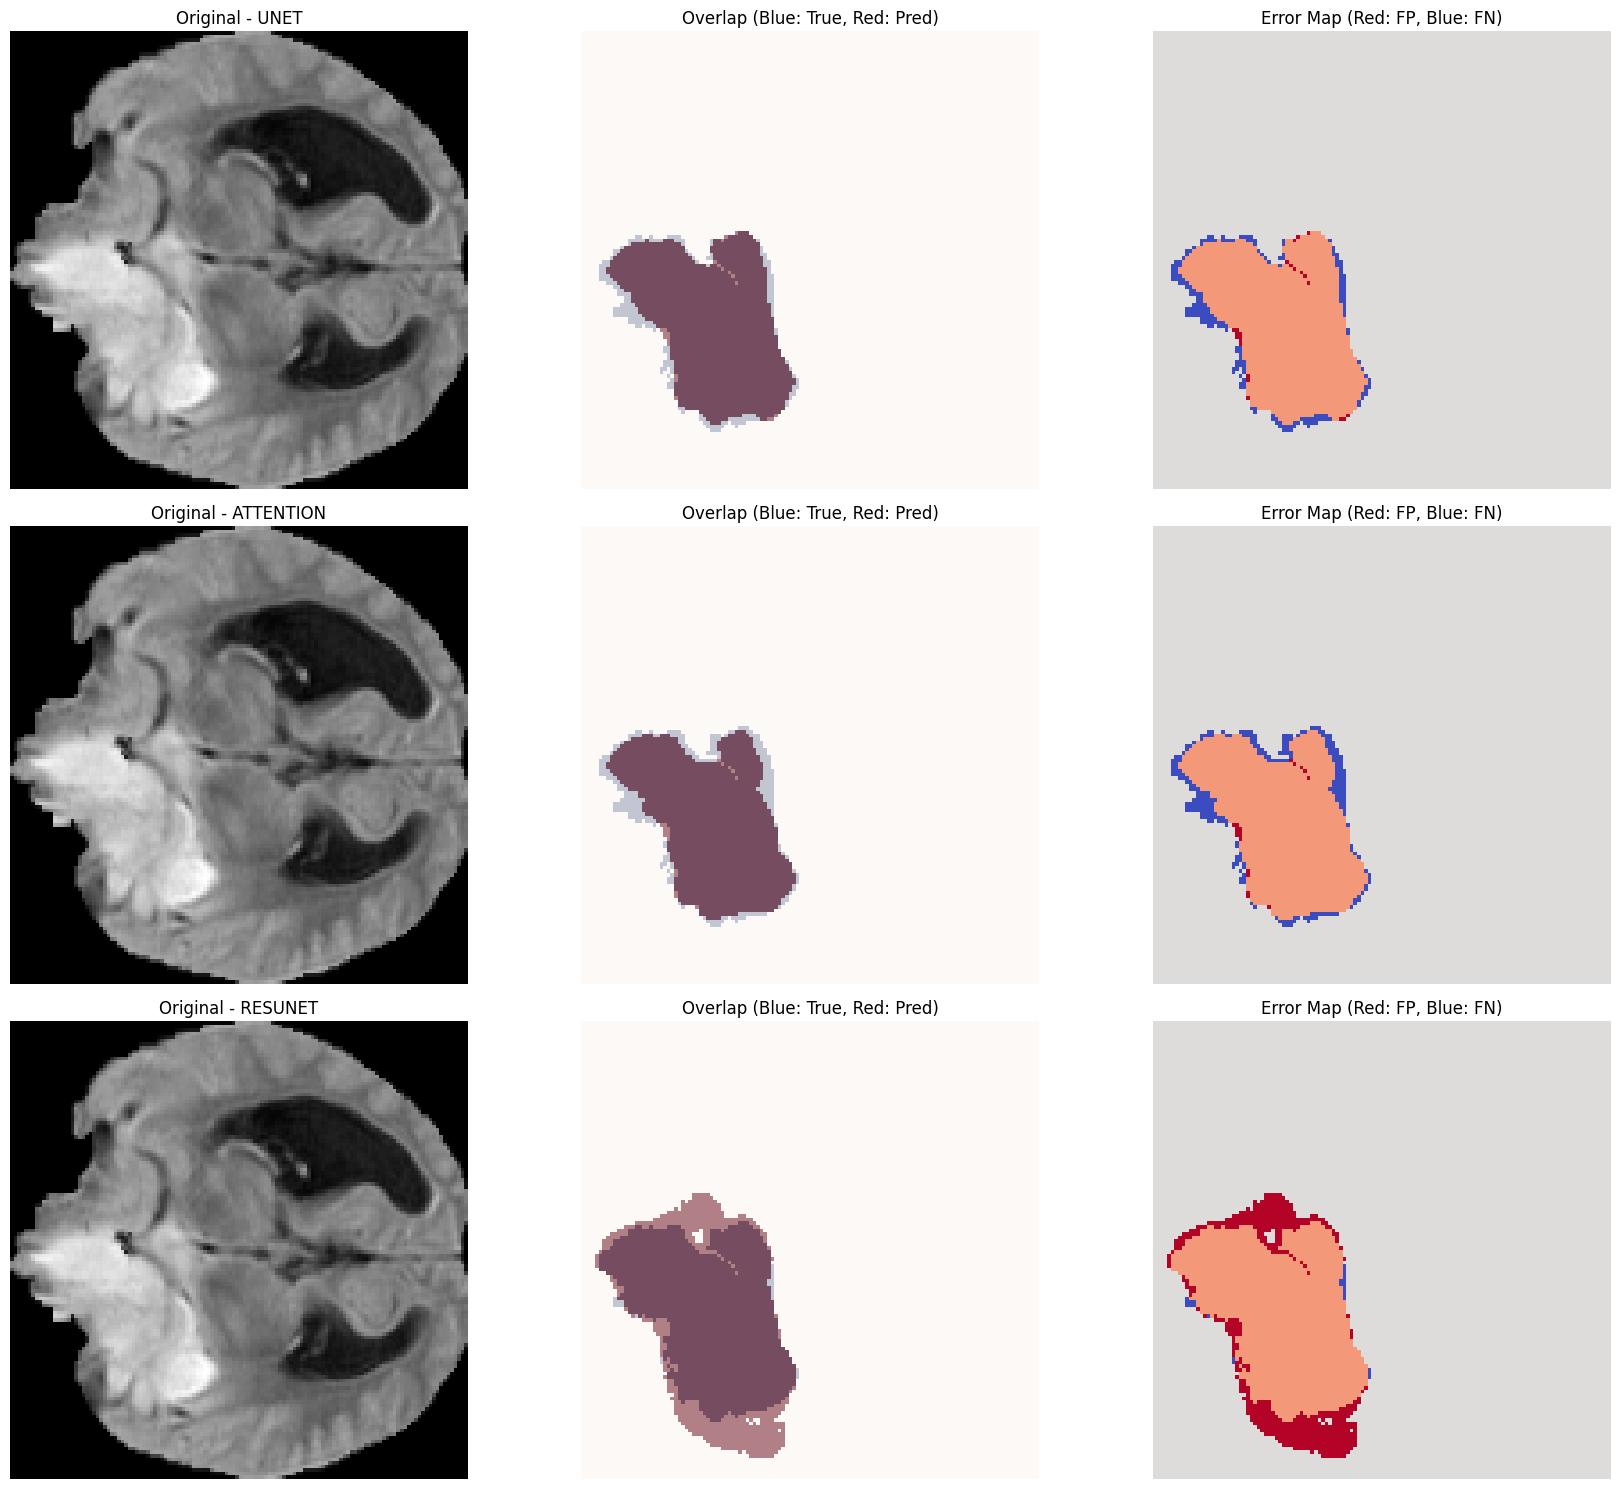

In [15]:
def plot_error_maps(model_dict, test_gen, patient_idx=10):
    X, y_true = test_gen[patient_idx]
    y_true_img = np.sum(y_true[0], axis=-1)

    fig, axes = plt.subplots(len(model_dict), 3, figsize=(18, 5 * len(model_dict)))

    for i, (name, model) in enumerate(model_dict.items()):
        y_pred = model.predict(X, verbose=0)[0]
        y_pred_img = np.sum(y_pred, axis=-1)
        y_pred_bin = (y_pred_img > 0.5).astype(float)
        y_true_bin = (y_true_img > 0.5).astype(float)

        # 1: Correct (Gray/White), 2: False Positive (Red), -1: False Negative (Blue)
        error_map = np.zeros_like(y_true_bin)
        error_map[(y_true_bin == 1) & (y_pred_bin == 1)] = 0.5
        error_map[(y_true_bin == 0) & (y_pred_bin == 1)] = 1.0
        error_map[(y_true_bin == 1) & (y_pred_bin == 0)] = -1.0

        axes[i][0].imshow(X[0, :, :, 0], cmap='gray')
        axes[i][0].set_title(f"Original - {name.upper()}")
        axes[i][0].axis('off')

        axes[i][1].imshow(y_true_bin, cmap='Blues', alpha=0.5)
        axes[i][1].imshow(y_pred_bin, cmap='Reds', alpha=0.5)
        axes[i][1].set_title("Overlap (Blue: True, Red: Pred)")
        axes[i][1].axis('off')

        im = axes[i][2].imshow(error_map, cmap='coolwarm', vmin=-1, vmax=1)
        axes[i][2].set_title("Error Map (Red: FP, Blue: FN)")
        axes[i][2].axis('off')

    plt.tight_layout()
    plt.show()

plot_error_maps(models, test_gen, patient_idx=10)

Hausdorff Distance 95 (HD95) Calculation


In [16]:
from scipy.spatial.distance import directed_hausdorff

def calculate_hd95(model_dict, test_gen, num_samples=20):
    hd95_results = {name: [] for name in model_dict.keys()}

    print(f"Calculating HD95 on {num_samples} samples...")
    for i in range(num_samples):
        X, y_true = test_gen[i]
        y_true_bin = (np.sum(y_true[0], axis=-1) > 0.5).astype(np.uint8)

        if np.sum(y_true_bin) == 0: continue

        for name, model in model_dict.items():
            y_pred = model.predict(X, verbose=0)[0]
            y_pred_bin = (np.sum(y_pred, axis=-1) > 0.5).astype(np.uint8)

            if np.sum(y_pred_bin) == 0:
                hd95_results[name].append(100.0)
                continue

            u = np.argwhere(y_true_bin)
            v = np.argwhere(y_pred_bin)
            hd = max(directed_hausdorff(u, v)[0], directed_hausdorff(v, u)[0])
            hd95_results[name].append(hd)

    hd_summary = []
    for name in model_dict.keys():
        hd_summary.append({
            "Model": name.upper(),
            "Avg Hausdorff Distance (Lower is better)": f"{np.mean(hd95_results[name]):.4f}"
        })

    return pd.DataFrame(hd_summary)

hd_df = calculate_hd95(models, test_gen)
display(hd_df)

Calculating HD95 on 20 samples...


,Model,Avg Hausdorff Distance (Lower is better)
0,UNET,15.5335
1,ATTENTION,17.0981
2,RESUNET,15.8594


Inference Speed Benchmark

In [18]:
for name, model in models.items():
    start_time = time.time()
    _ = model.predict(test_gen[0][0], verbose=0)

    start_time = time.time()
    for _ in range(50):
        _ = model.predict(test_gen[0][0], verbose=0)
    avg_time = (time.time() - start_time) / 50 * 1000

    print(f"{name.upper()} Average Inference Time: {avg_time:.2f} ms")

UNET Average Inference Time: 1195.17 ms
ATTENTION Average Inference Time: 1093.28 ms
RESUNET Average Inference Time: 1134.92 ms


Prediction Confidence Distribution


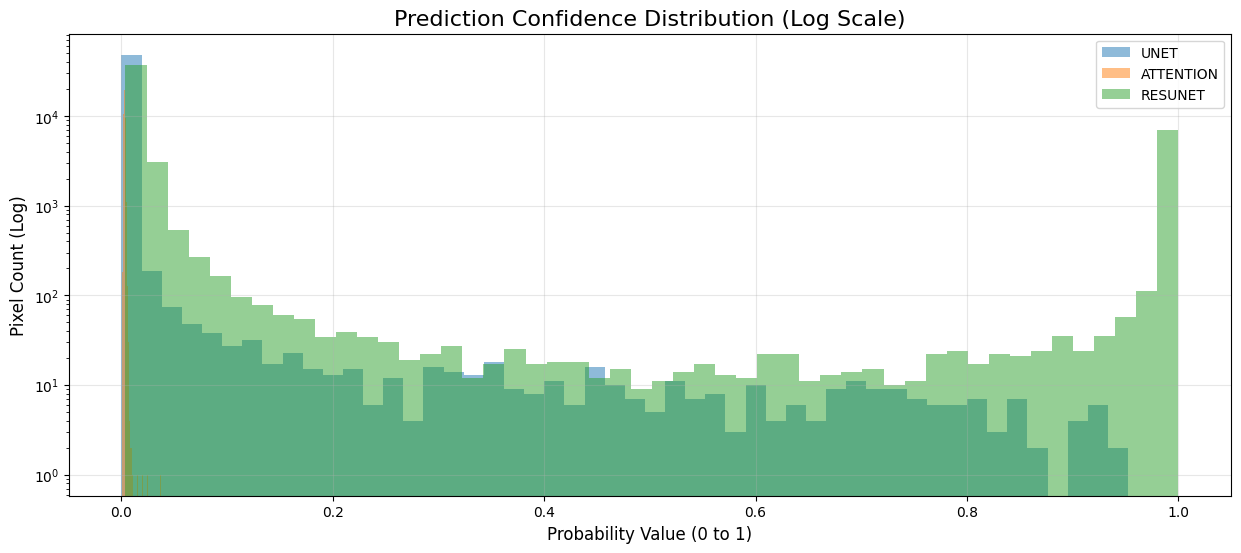

In [19]:
plt.figure(figsize=(15, 6))

for name, model in models.items():
    X, _ = test_gen[10]
    preds = model.predict(X, verbose=0).flatten()

    plt.hist(preds, bins=50, alpha=0.5, label=f'{name.upper()}', color=colors[name], log=True)

plt.title('Prediction Confidence Distribution (Log Scale)', fontsize=16)
plt.xlabel('Probability Value (0 to 1)', fontsize=12)
plt.ylabel('Pixel Count (Log)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Uncertainty Mapping


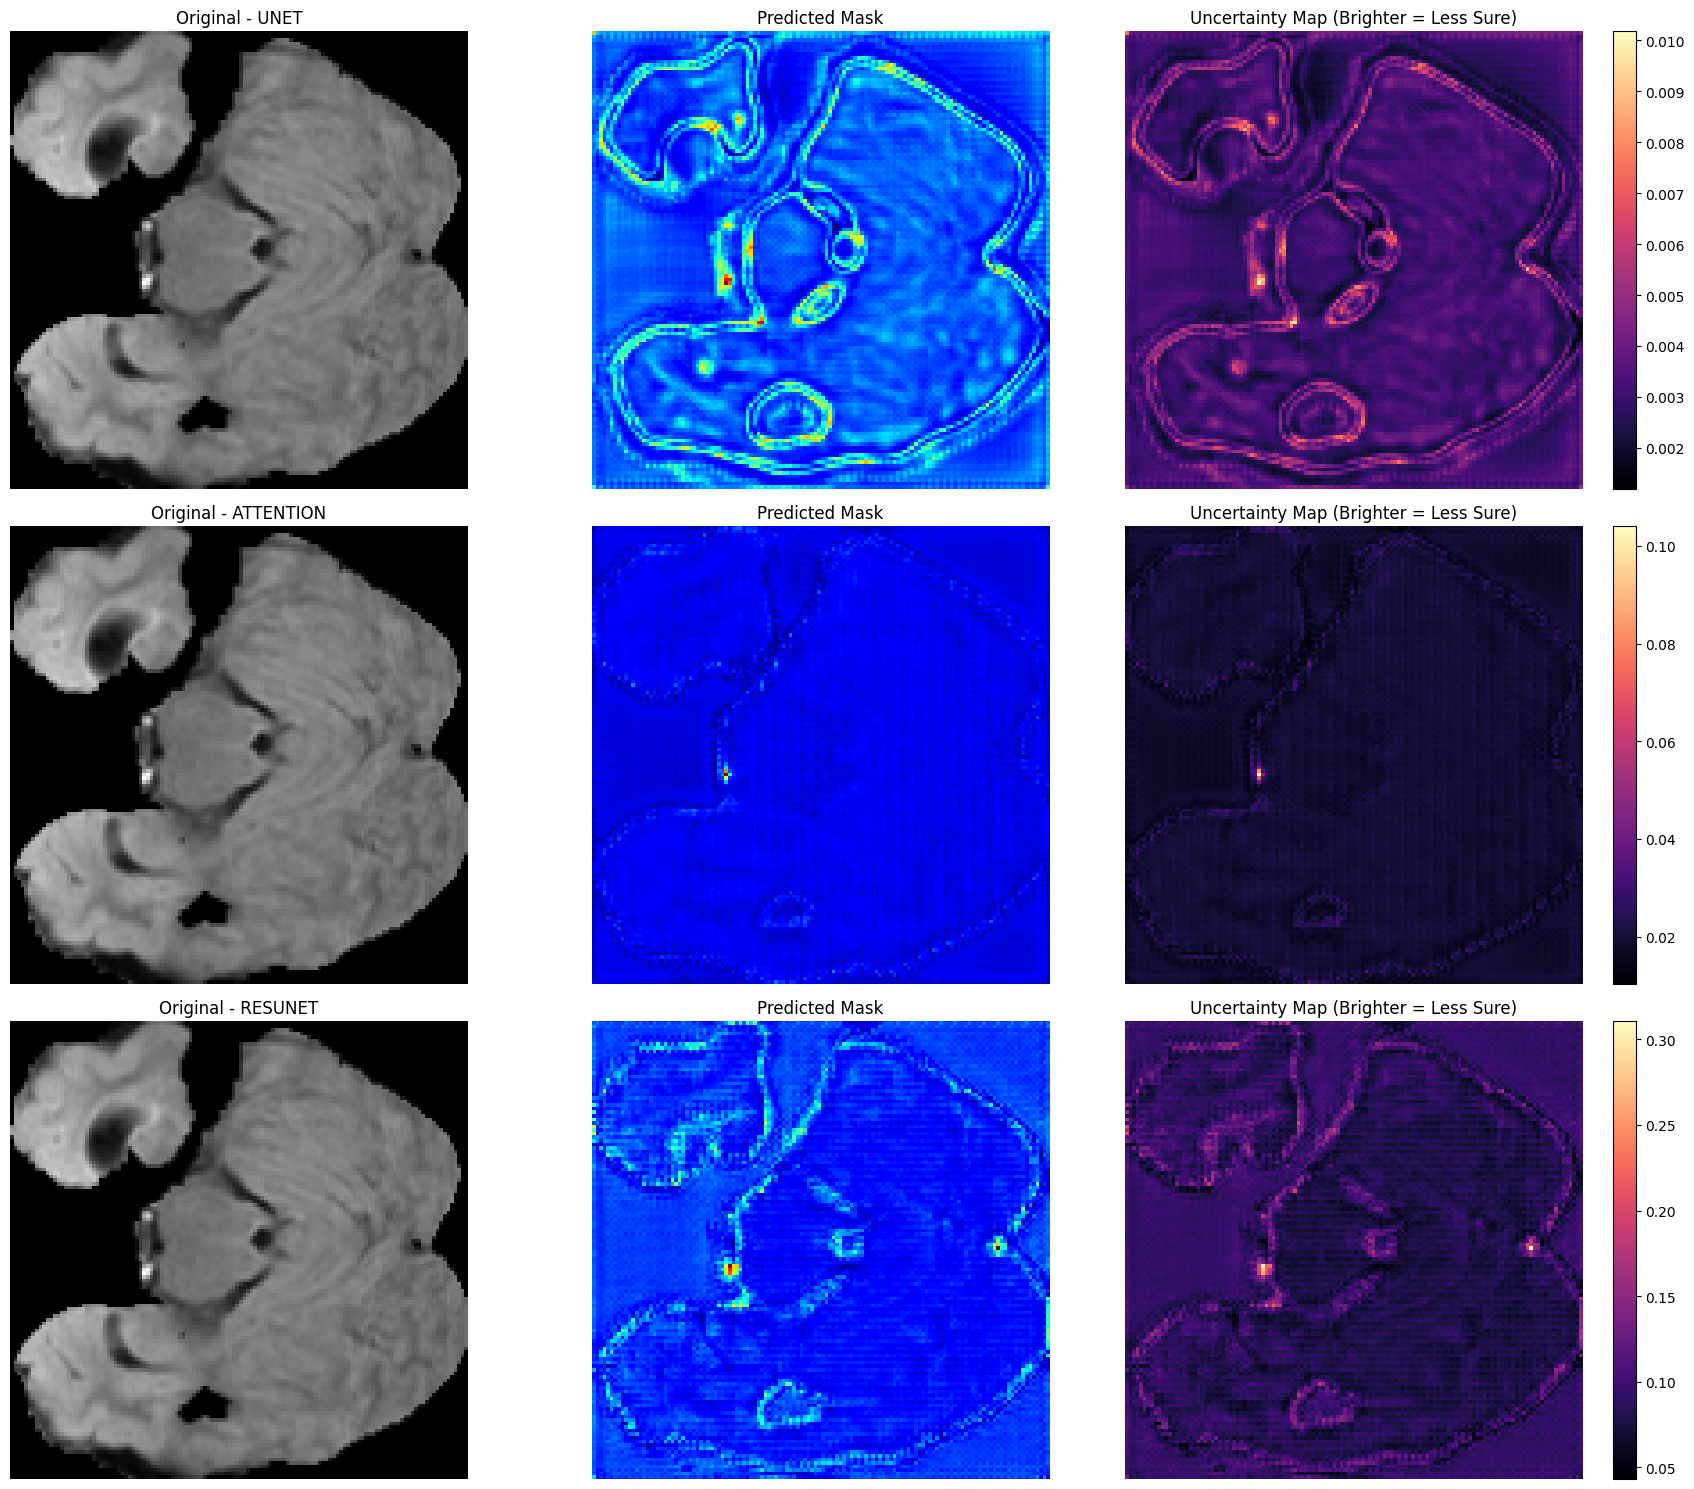

In [20]:
def plot_uncertainty_maps(model_dict, test_gen, patient_idx=10):
    X, y_true = test_gen[patient_idx]

    fig, axes = plt.subplots(len(model_dict), 3, figsize=(18, 5 * len(model_dict)))

    for i, (name, model) in enumerate(model_dict.items()):
        pred = model.predict(X, verbose=0)[0]
        pred_img = np.sum(pred, axis=-1)

        uncertainty = 1 - np.abs(2 * pred_img - 1)

        axes[i][0].imshow(X[0, :, :, 0], cmap='gray')
        axes[i][0].set_title(f"Original - {name.upper()}")
        axes[i][0].axis('off')

        axes[i][1].imshow(pred_img, cmap='jet')
        axes[i][1].set_title("Predicted Mask")
        axes[i][1].axis('off')

        im = axes[i][2].imshow(uncertainty, cmap='magma')
        axes[i][2].set_title("Uncertainty Map (Brighter = Less Sure)")
        plt.colorbar(im, ax=axes[i][2])
        axes[i][2].axis('off')

    plt.tight_layout()
    plt.show()

plot_uncertainty_maps(models, test_gen, patient_idx=10)

Performance Analysis by Tumor Size


In [21]:
def analyze_by_size(model_dict, test_gen, num_samples=30):
    results = {name: {'Small': [], 'Medium': [], 'Large': []} for name in model_dict.keys()}

    print(f"Analyzing {num_samples} samples by tumor size...")
    for i in range(num_samples):
        X, y_true = test_gen[i]
        true_mask = (np.sum(y_true[0], axis=-1) > 0.5).astype(int)
        tumor_area = np.sum(true_mask)

        if tumor_area == 0: continue

        if tumor_area < 500: size_cat = 'Small'
        elif tumor_area < 2000: size_cat = 'Medium'
        else: size_cat = 'Large'

        for name, model in model_dict.items():
            pred = model.predict(X, verbose=0)[0]
            pred_bin = (np.sum(pred, axis=-1) > 0.5).astype(int)

            inter = np.sum(true_mask * pred_bin)
            dice = (2. * inter) / (np.sum(true_mask) + np.sum(pred_bin) + 1e-7)
            results[name][size_cat].append(dice)

    size_summary = []
    for name in model_dict.keys():
        size_summary.append({
            'Model': name.upper(),
            'Small Tumor Dice': np.mean(results[name]['Small']) if results[name]['Small'] else 0,
            'Medium Tumor Dice': np.mean(results[name]['Medium']) if results[name]['Medium'] else 0,
            'Large Tumor Dice': np.mean(results[name]['Large']) if results[name]['Large'] else 0
        })

    display(pd.DataFrame(size_summary))

analyze_by_size(models, test_gen)

Analyzing 30 samples by tumor size...


,Model,Small Tumor Dice,Medium Tumor Dice,Large Tumor Dice
0,UNET,0.200379,0.832441,0.900135
1,ATTENTION,0.233297,0.781172,0.862255
2,RESUNET,0.192695,0.793675,0.874321


External Validation on Unseen Data (No Ground Truth)

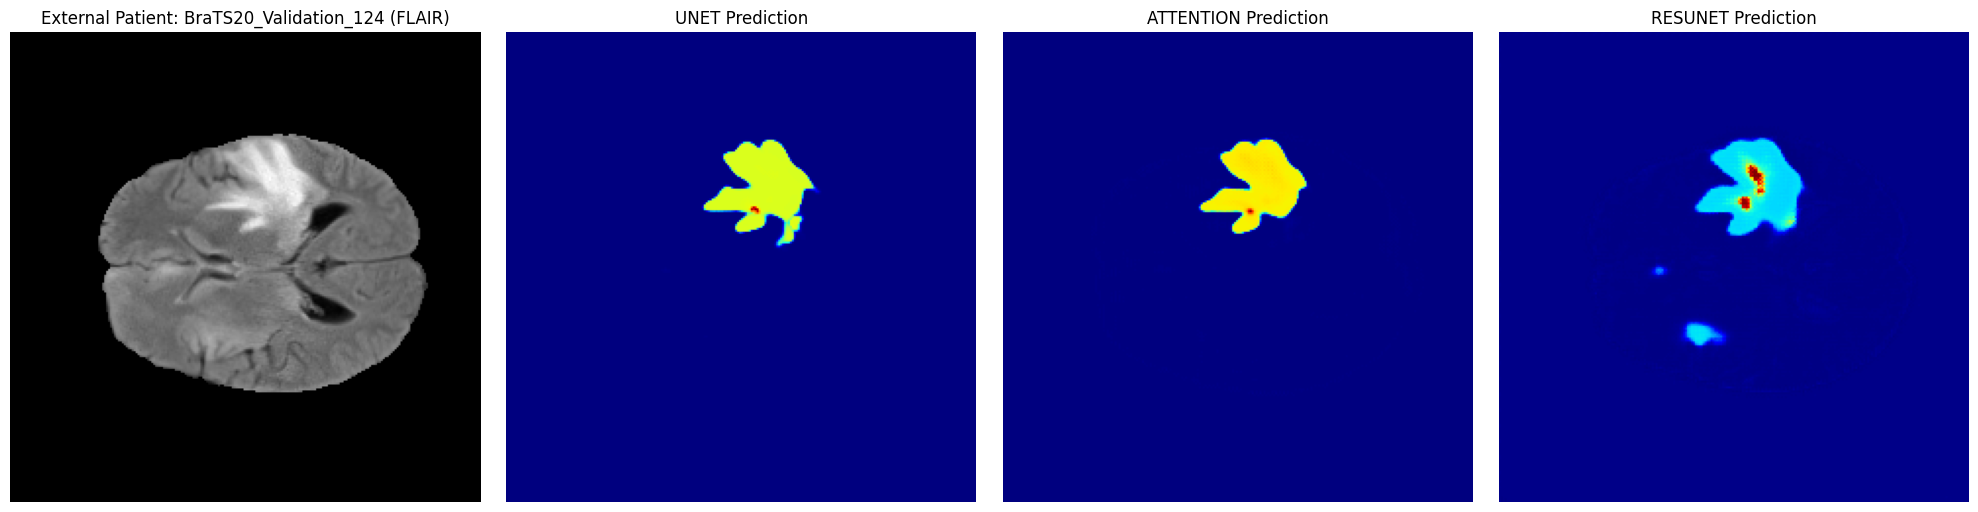

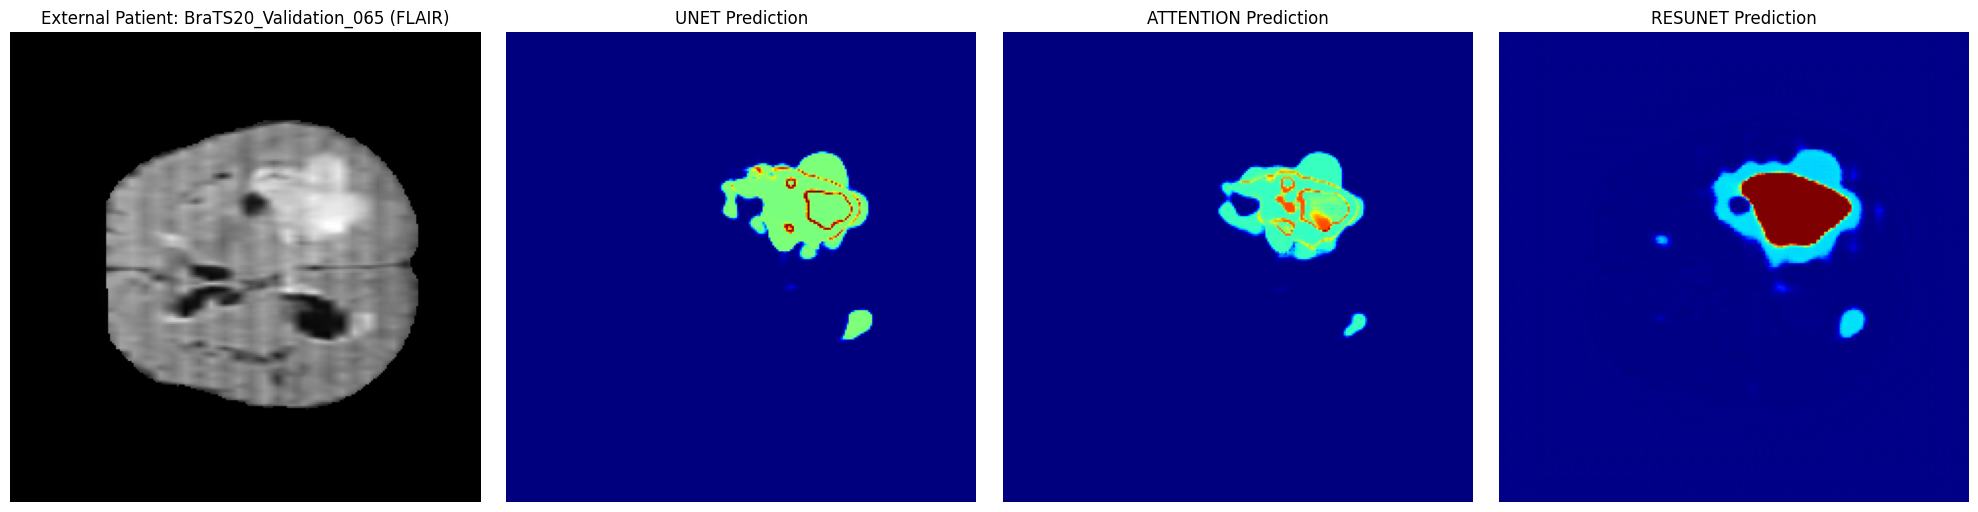

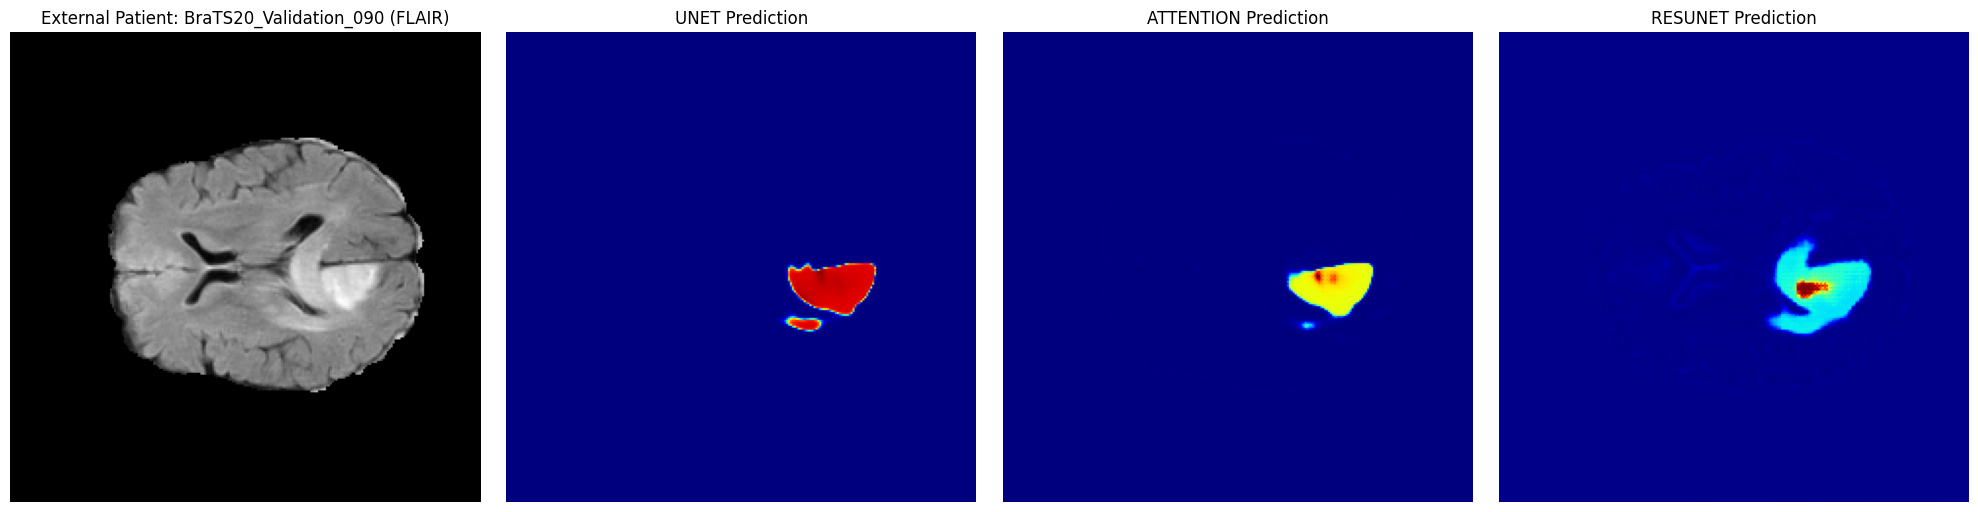

In [24]:
VAL_DATA_PATH = "/content/drive/MyDrive/BraTS_Project/data/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData"
val_patient_ids = sorted([f for f in os.listdir(VAL_DATA_PATH) if os.path.isdir(os.path.join(VAL_DATA_PATH, f))])

def run_external_validation(model_dict, val_path, val_ids, num_samples=3):
    selected_ids = np.random.choice(val_ids, num_samples, replace=False)
    modalities = ['flair', 't1', 't1ce', 't2']

    for p_id in selected_ids:
        patient_path = os.path.join(val_path, p_id)
        images = []

        for mod in modalities:
            img_path = os.path.join(patient_path, f"{p_id}_{mod}.nii")
            img_data = nib.load(img_path).get_fdata()

            slice_data = img_data[:, :, 75]

            slice_norm = (slice_data - np.min(slice_data)) / (np.max(slice_data) - np.min(slice_data) + 1e-7)
            images.append(slice_norm)

        X_stacked = np.stack(images, axis=-1)
        X_input = np.expand_dims(X_stacked, axis=0)

        fig, axes = plt.subplots(1, 4, figsize=(20, 5))

        axes[0].imshow(X_stacked[:, :, 0], cmap='gray')
        axes[0].set_title(f"External Patient: {p_id} (FLAIR)", fontsize=12)
        axes[0].axis('off')

        for i, (name, model) in enumerate(model_dict.items()):
            pred = model.predict(X_input, verbose=0)[0]
            pred_img = np.sum(pred, axis=-1)

            axes[i+1].imshow(pred_img, cmap='jet')
            axes[i+1].set_title(f"{name.upper()} Prediction", fontsize=12)
            axes[i+1].axis('off')

        plt.tight_layout()
        plt.show()

run_external_validation(models, VAL_DATA_PATH, val_patient_ids)